In [ ]:
import pandas as pd

df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv")
df.shape

(13399, 19)

In [ ]:
import pandas as pd
import numpy as np

# Load your cleaned dataset
df = pd.read_csv('BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv')

# Ensure hypertension is binary (1=Yes, 0=No)
# Calculate weighted prevalence
weighted_prevalence = (
    (df['hypertension'] * df['sample_weight']).sum() /
    df['sample_weight'].sum()
)

print(f"Weighted Hypertension Prevalence: {weighted_prevalence*100:.1f}%")

Weighted Hypertension Prevalence: 20.2%


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load data
df = pd.read_csv('BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv')

# Extract variables
y = df['hypertension'].values          # Binary outcome: 1=hypertensive, 0=normotensive
w = df['sample_weight'].values         # Survey weights

# Weighted prevalence (proportion)
p_hat = np.sum(w * y) / np.sum(w)

# Effective sample size (Kish approximation)
n_eff = (np.sum(w) ** 2) / np.sum(w ** 2)

# Weighted standard error (binomial approximation with design effect)
# Design effect approximation: deff = 1 + (m - 1) * ICC, but we use weighted variance
weighted_var = np.sum(w * (y - p_hat) ** 2) / ((np.sum(w) - 1) * np.sum(w) / np.sum(w))
se = np.sqrt(weighted_var / n_eff)

# 95% Confidence Interval
z = 1.96  # Normal approximation
ci_lower = p_hat - z * se
ci_upper = p_hat + z * se

print(f"Weighted Prevalence: {p_hat*100:.1f}%")
print(f"95% CI: {ci_lower*100:.1f}% – {ci_upper*100:.1f}%")
print(f"Effective Sample Size (n_eff): {n_eff:,.0f}")

Weighted Prevalence: 20.2%
95% CI: 19.4% – 21.0%
Effective Sample Size (n_eff): 10,697


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.weightstats import DescrStatsW

# Load data
df = pd.read_csv('BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv')

# Create survey-weighted descriptive statistics object
weighted_stats = DescrStatsW(df['hypertension'], weights=df['sample_weight'])

# Weighted mean = prevalence
prevalence = weighted_stats.mean
se = weighted_stats.std_mean  # Standard error of the mean

# 95% CI using t-distribution (more conservative for survey data)
ci = weighted_stats.tconfint_mean(alpha=0.05)

print(f"Weighted Hypertension Prevalence: {prevalence*100:.1f}%")
print(f"Standard Error: {se*100:.2f}%")
print(f"95% Confidence Interval: {ci[0]*100:.1f}% – {ci[1]*100:.1f}%")

Weighted Hypertension Prevalence: 20.2%
Standard Error: 0.35%
95% Confidence Interval: 19.5% – 20.9%


In [ ]:
# Calculate weighted prevalence by age group
def weighted_prevalence_by_group(df, group_var, outcome_var='hypertension', weight_var='sample_weight'):
    results = []
    for group in df[group_var].unique():
        subset = df[df[group_var] == group]
        prev = (subset[outcome_var] * subset[weight_var]).sum() / subset[weight_var].sum()
        n = len(subset)
        results.append({
            group_var: group,
            'Prevalence_%': round(prev * 100, 1),
            'N_unweighted': n,
            'N_weighted': round(subset[weight_var].sum(), 0)
        })
    return pd.DataFrame(results)

# Example: Prevalence by age_group
age_prevalence = weighted_prevalence_by_group(df, 'age_group')
print(age_prevalence.to_string(index=False))

age_group  Prevalence_%  N_unweighted  N_weighted
      70+          44.4           769       763.0
    50-59          33.7          1774      1728.0
    40-49          23.8          2401      2338.0
    30-39          14.7          3047      2992.0
    18-29           4.8          4023      3885.0
    60-69          39.4          1385      1343.0


In [ ]:
#!/usr/bin/env python3
"""
Calculate survey-weighted hypertension prevalence from BDHS 2022 data
Author: [Your Name]
Date: [Date]
"""

import pandas as pd
import numpy as np
from statsmodels.stats.weightstats import DescrStatsW

# Load data
df = pd.read_csv('BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv')

# Validate data
assert 'hypertension' in df.columns, "Missing 'hypertension' column"
assert 'sample_weight' in df.columns, "Missing 'sample_weight' column"
assert df['hypertension'].isin([0, 1]).all(), "Hypertension must be binary (0/1)"

# Calculate weighted prevalence
weighted_stats = DescrStatsW(df['hypertension'], weights=df['sample_weight'])
prevalence = weighted_stats.mean
se = weighted_stats.std_mean
ci = weighted_stats.tconfint_mean(alpha=0.05)

# Print results
print("="*60)
print("BDHS 2022: Weighted Hypertension Prevalence")
print("="*60)
print(f"Analytic Sample Size (unweighted): {len(df):,}")
print(f"Weighted Population Estimate: {df['sample_weight'].sum():,.0f}")
print(f"Weighted Prevalence: {prevalence*100:.1f}%")
print(f"Standard Error: {se*100:.2f}%")
print(f"95% Confidence Interval: {ci[0]*100:.1f}% – {ci[1]*100:.1f}%")
print("="*60)

BDHS 2022: Weighted Hypertension Prevalence
Analytic Sample Size (unweighted): 13,399
Weighted Population Estimate: 13,050
Weighted Prevalence: 20.2%
Standard Error: 0.35%
95% Confidence Interval: 19.5% – 20.9%


Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: SVM
Training: XGBoost
Training: MLP

FINAL HOLDOUT RESULTS
                      Model  Accuracy   AUC  PR_AUC  Kappa  Precision  Recall    F1  Brier  Sensitivity  Specificity
Logistic Regression (Train)     0.706 0.797   0.492  0.328      0.385   0.747 0.508  0.185        0.747        0.696
  Logistic Regression (Val)     0.698 0.768   0.457  0.306      0.372   0.720 0.491  0.191        0.720        0.693
 Logistic Regression (Test)     0.711 0.793   0.508  0.347      0.410   0.752 0.531  0.185        0.752        0.699
      Decision Tree (Train)     0.732 0.838   0.555  0.384      0.417   0.800 0.548  0.169        0.800        0.715
        Decision Tree (Val)     0.697 0.751   0.416  0.296      0.368   0.700 0.482  0.197        0.700        0.696
       Decision Tree (Test)     0.739 0.823   0.548  0.395      0.443   0.770 0.562  0.171        0.770        0.731
      Random Forest (Train)     0.

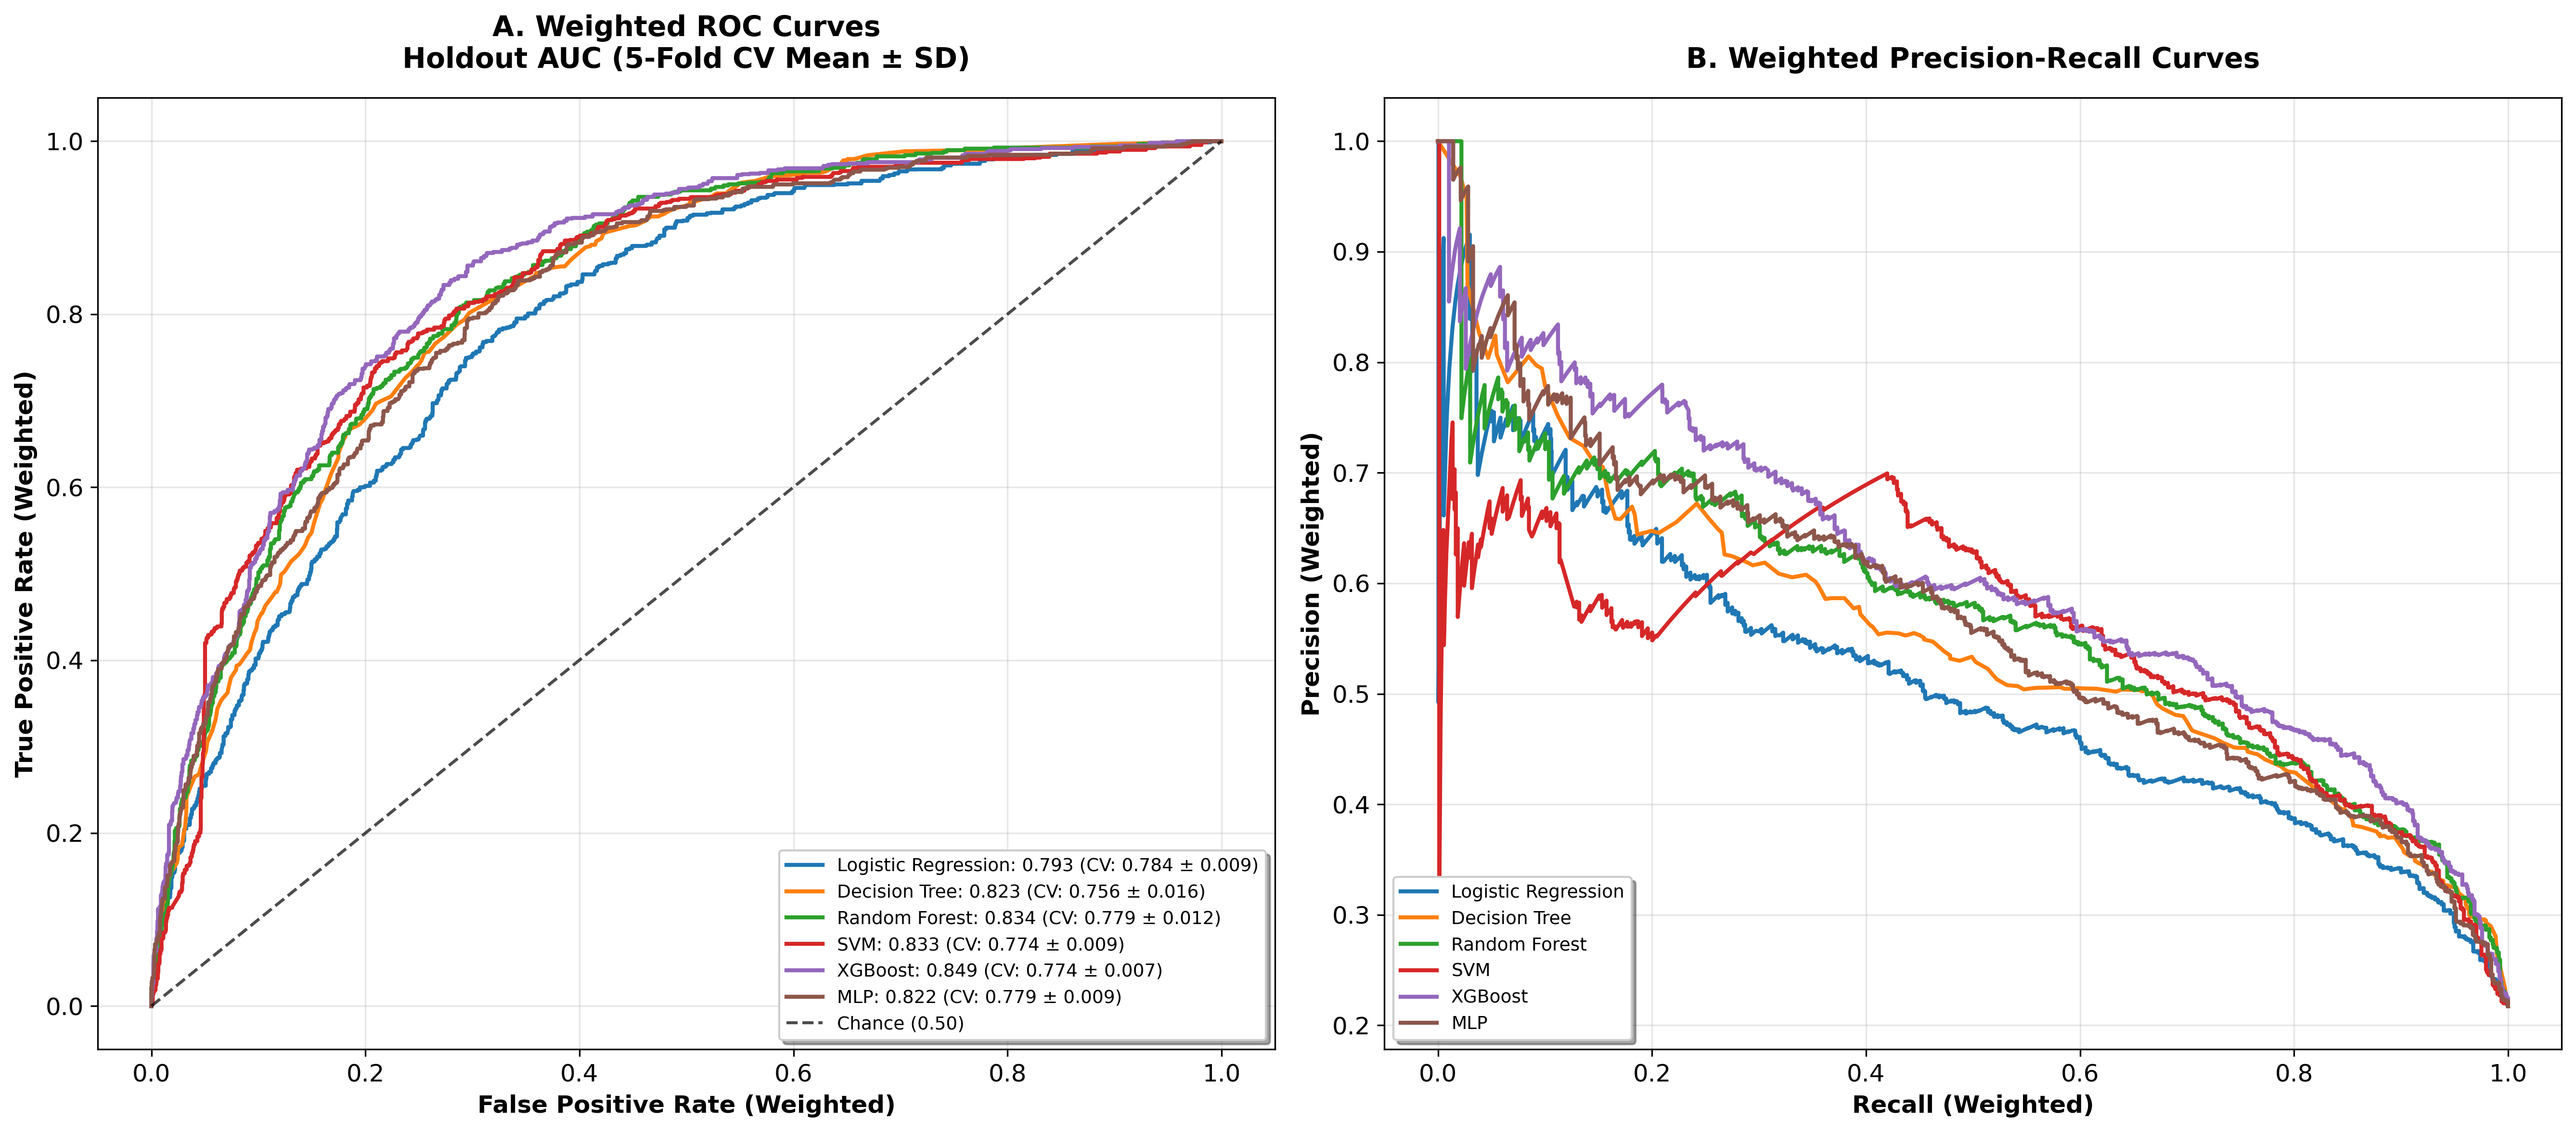

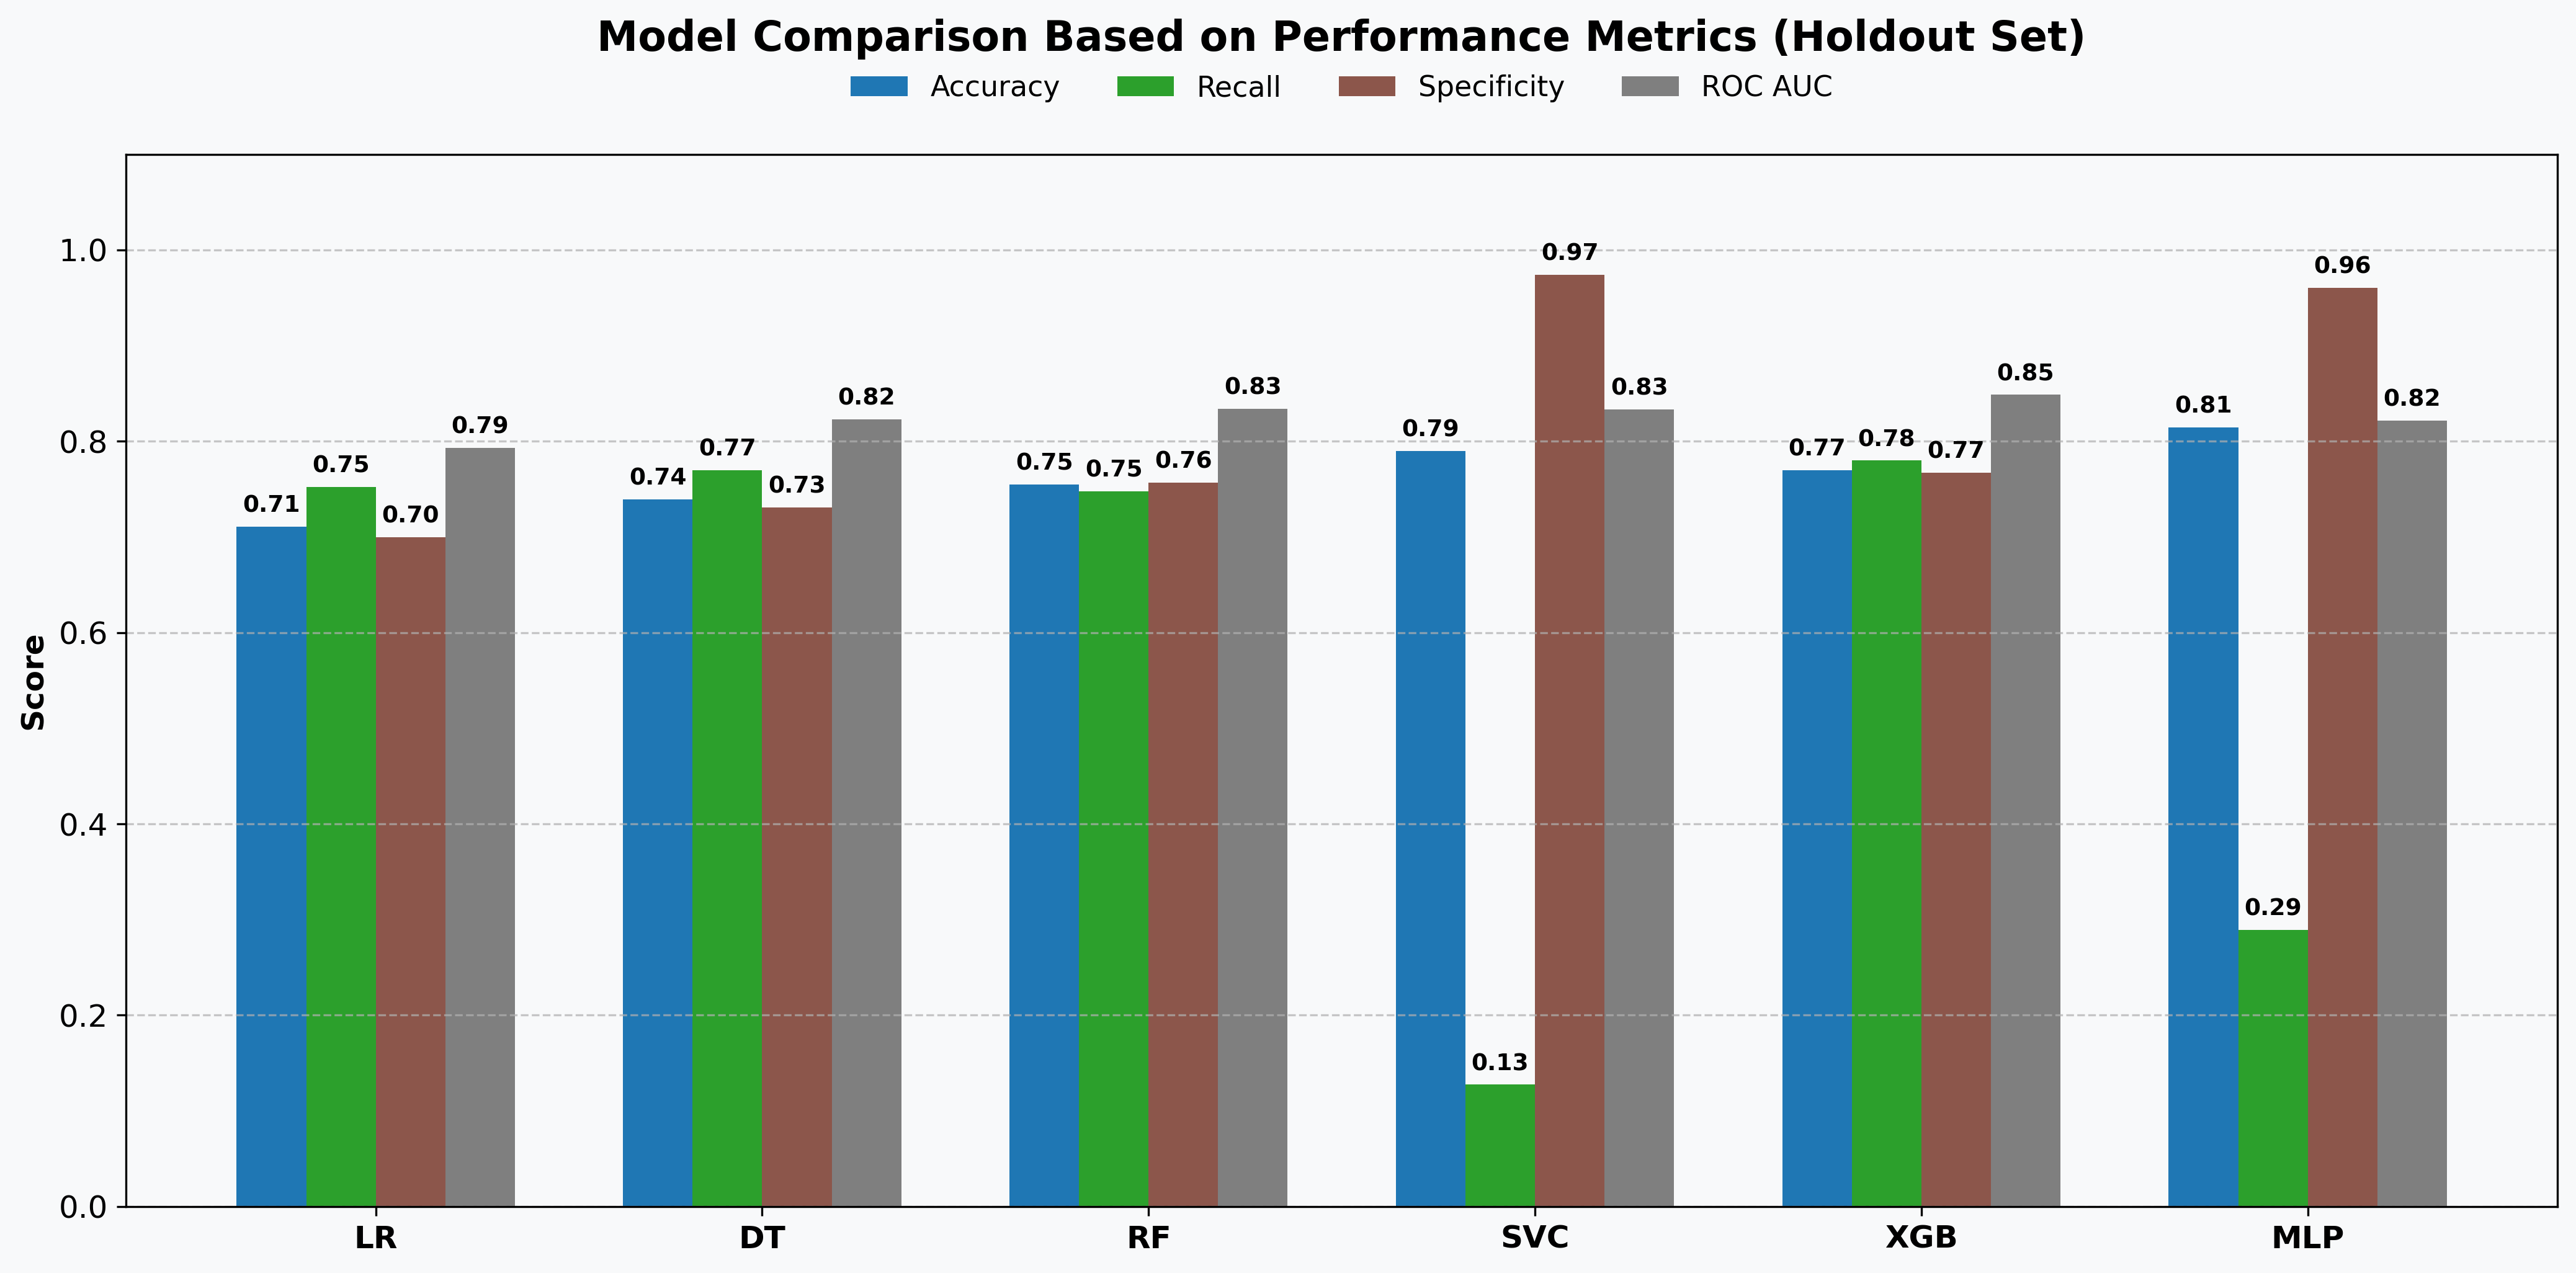

In [ ]:
# ==============================================================
# BDHS SURVEY-AWARE MACHINE LEARNING PIPELINE (FIXED VERSION)
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    brier_score_loss,
    average_precision_score,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ==============================================================
# PUBLICATION-QUALITY FIGURE SETTINGS
# ==============================================================
plt.style.use("default")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 300
})

# ==============================================================
# 1. LOAD DATA
# ==============================================================
# Ensure path is correct for your environment
df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv")

target = "hypertension"
design_cols = ["cluster_id", "strata_id", "sample_weight"]

df[target] = df[target].astype(int)

# ==============================================================
# 2. CATEGORICAL VARIABLES & PREPROCESSING
# ==============================================================
categorical_vars = [
    'age_group', 'sex', 'education_level', 'marital_status',
    'residence_type', 'division', 'wealth_index', 'BMI_category',
    'diabetes', 'household_size_cat', 'crowding_category',
    'electricity', 'improved_water', 'improved_toilet', 'mobile_phone'
]

for col in categorical_vars:
    df[col] = df[col].astype(str)

# One-Hot Encoding
X = pd.get_dummies(df.drop(columns=[target] + design_cols), drop_first=True)
y = df[target]
w = df["sample_weight"]
clusters = df["cluster_id"]

# ==============================================================
# 4. TRAIN / VALIDATION / TEST SPLIT (CLUSTER-AWARE)
# ==============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups=clusters))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(gss2.split(
    X.iloc[train_val_idx],
    y.iloc[train_val_idx],
    groups=clusters.iloc[train_val_idx]
))

X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
y_train, y_val, y_test = y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]
w_train, w_val, w_test = w.iloc[train_idx], w.iloc[val_idx], w.iloc[test_idx]

# ==============================================================
# 5. METRIC FUNCTIONS (WEIGHTED)
# ==============================================================
def pr_auc(y_true, p, w):
    # Fixed: average_precision_score supports sample_weight
    return average_precision_score(y_true, p, sample_weight=w)

def evaluate_metrics(y_true, p, w, threshold=0.5):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, sample_weight=w).ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "Accuracy": accuracy_score(y_true, pred, sample_weight=w),
        "AUC": roc_auc_score(y_true, p, sample_weight=w),
        "PR_AUC": pr_auc(y_true, p, w),
        "Kappa": cohen_kappa_score(y_true, pred, sample_weight=w),
        "Precision": precision_score(y_true, pred, sample_weight=w),
        "Recall": recall_score(y_true, pred, sample_weight=w),
        "F1": f1_score(y_true, pred, sample_weight=w),
        "Brier": brier_score_loss(y_true, p, sample_weight=w),
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }

# ==============================================================
# 6. MODELS
# ==============================================================
ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
     "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "SVM": SVC(
        C=1, kernel="rbf",gamma="scale", probability=True, class_weight="balanced", random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=1000, max_depth=4, learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5, gamma=0.2, reg_alpha=0.1,
        reg_lambda=1, scale_pos_weight=ratio,
        eval_metric="auc", tree_method="hist", random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
        alpha=0.001, early_stopping=True, max_iter=500, random_state=42
    )
}

# ==============================================================
# 7. HOLDOUT EVALUATION
# ==============================================================
master_results = []
roc_plot_data = {}
pr_plot_data = {}

for name, model in models.items():
    print(f"Training: {name}")

    # MLP does NOT support sample_weight in sklearn fit()
    if name == "MLP":
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=w_train)

    p_test = model.predict_proba(X_test)[:, 1]
    p_train = model.predict_proba(X_train)[:, 1]
    p_val = model.predict_proba(X_val)[:, 1]

    # Metrics
    train_m = evaluate_metrics(y_train, p_train, w_train)
    val_m = evaluate_metrics(y_val, p_val, w_val)
    test_m = evaluate_metrics(y_test, p_test, w_test)

    master_results.append([f"{name} (Train)"] + list(train_m.values()))
    master_results.append([f"{name} (Val)"] + list(val_m.values()))
    master_results.append([f"{name} (Test)"] + list(test_m.values()))

    roc_plot_data[name] = p_test
    pr_plot_data[name] = p_test

# ==============================================================
# 8. RESULTS TABLE
# ==============================================================
cols = ["Model", "Accuracy", "AUC", "PR_AUC", "Kappa", "Precision",
        "Recall", "F1", "Brier", "Sensitivity", "Specificity"]

results_df = pd.DataFrame(master_results, columns=cols)
print("\n" + "="*110)
print("FINAL HOLDOUT RESULTS")
print("="*110)
print(results_df.round(3).to_string(index=False))

# ==============================================================
# 9. 5-FOLD GROUP CROSS-VALIDATION
# ==============================================================
gkf = GroupKFold(n_splits=5)
cv_results = []

for name, model in models.items():
    print(f"CV Progress: {name}")
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=clusters)):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr, w_te = w.iloc[tr], w.iloc[te]

        if name == "MLP":
            model.fit(X_tr, y_tr)
        else:
            model.fit(X_tr, y_tr, sample_weight=w_tr)

        p = model.predict_proba(X_te)[:, 1]
        metrics = evaluate_metrics(y_te, p, w_te)
        metrics["Model"] = name
        cv_results.append(metrics)

cv_df = pd.DataFrame(cv_results)
summary = cv_df.groupby("Model").agg({
    "AUC": ["mean", "std"],
    "PR_AUC": ["mean", "std"],
    "Sensitivity": ["mean", "std"],
    "Specificity": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "F1": ["mean", "std"],
    "Accuracy": ["mean", "std"]
}).round(3)
print("\nCV SUMMARY:\n", summary)

# ==============================================================
# 10. VISUALIZATION 1: ROC & PR CURVES (REFINED)
# ==============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Pre-calculate CV summary for legend access (matching your summary logic)
cv_lookup = cv_df.groupby("Model")["AUC"].agg(["mean", "std"]).to_dict('index')

for name, probs in roc_plot_data.items():
    # 1. Calculate Weighted ROC Curve for Holdout Set
    fpr, tpr, _ = roc_curve(y_test, probs, sample_weight=w_test)
    holdout_auc = roc_auc_score(y_test, probs, sample_weight=w_test)

    # 2. Retrieve CV Mean and SD
    cv_mean = cv_lookup[name]['mean']
    cv_std = cv_lookup[name]['std']

    # 3. Format legend label
    label_str = f"{name}: {holdout_auc:.3f} (CV: {cv_mean:.3f} ± {cv_std:.3f})"

    # Plot ROC
    ax1.plot(fpr, tpr, linewidth=2, label=label_str)

    # 4. Weighted PR Curve
    precision, recall, _ = precision_recall_curve(y_test, probs, sample_weight=w_test)
    ax2.plot(recall, precision, linewidth=2, label=name)

# --- Styling ax1 (ROC) ---
ax1.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.7, label="Chance (0.50)")
ax1.set_xlabel("False Positive Rate (Weighted)", fontsize=12, fontweight='bold')
ax1.set_ylabel("True Positive Rate (Weighted)", fontsize=12, fontweight='bold')
ax1.set_title("A. Weighted ROC Curves\nHoldout AUC (5-Fold CV Mean ± SD)", fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc="lower right", frameon=True, fontsize=9, shadow=True)
ax1.grid(alpha=0.3)

# --- Styling ax2 (PR Curve) ---
ax2.set_xlabel("Recall (Weighted)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Precision (Weighted)", fontsize=12, fontweight='bold')
ax2.set_title("B. Weighted Precision-Recall Curves", fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc="lower left", frameon=True, fontsize=9, shadow=True)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ROC_PR_Comparison.png", dpi=300)
plt.show()

# ==============================================================
# 11. VISUALIZATION 2: PERFORMANCE BAR CHART (REFINED)
# ==============================================================
# Filter results_df to only include the "Test" rows for plotting
plot_df = results_df[results_df['Model'].str.contains("(Test)")].copy()

name_mapping = {
    "Logistic Regression (Test)": "LR",
    "Decision Tree (Test)": "DT",
    "Random Forest (Test)": "RF",
    "SVM (Test)": "SVC",
    "XGBoost (Test)": "XGB",
    "MLP (Test)": "MLP"
}

plot_df['Model_Short'] = plot_df['Model'].map(name_mapping)

metrics_to_plot = ["Accuracy", "Recall", "Specificity", "AUC"]
display_labels = ['Accuracy', 'Recall', 'Specificity', 'ROC AUC']
colors = ['#1f77b4', '#2ca02c', '#8c564b', '#7f7f7f']

x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

for i, col in enumerate(metrics_to_plot):
    bars = ax.bar(x + i*width, plot_df[col], width, label=display_labels[i], color=colors[i])

    # Annotate values on top of bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', rotation=0, fontsize=9, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_df['Model_Short'], fontweight='bold')
ax.set_title("Model Comparison Based on Performance Metrics (Holdout Set)",
             fontweight='bold', fontsize=16, pad=40)
ax.set_ylabel("Score", fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4, frameon=False, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Model_Metrics_Comparison.png", dpi=300)
plt.show()


Running CV: Logistic Regression
Running CV: Decision Tree
Running CV: Random Forest
Running CV: SVM
Running CV: XGBoost
Running CV: MLP
Training Final: Logistic Regression
Training Final: Decision Tree
Training Final: Random Forest
Training Final: SVM
Training Final: XGBoost
Training Final: MLP


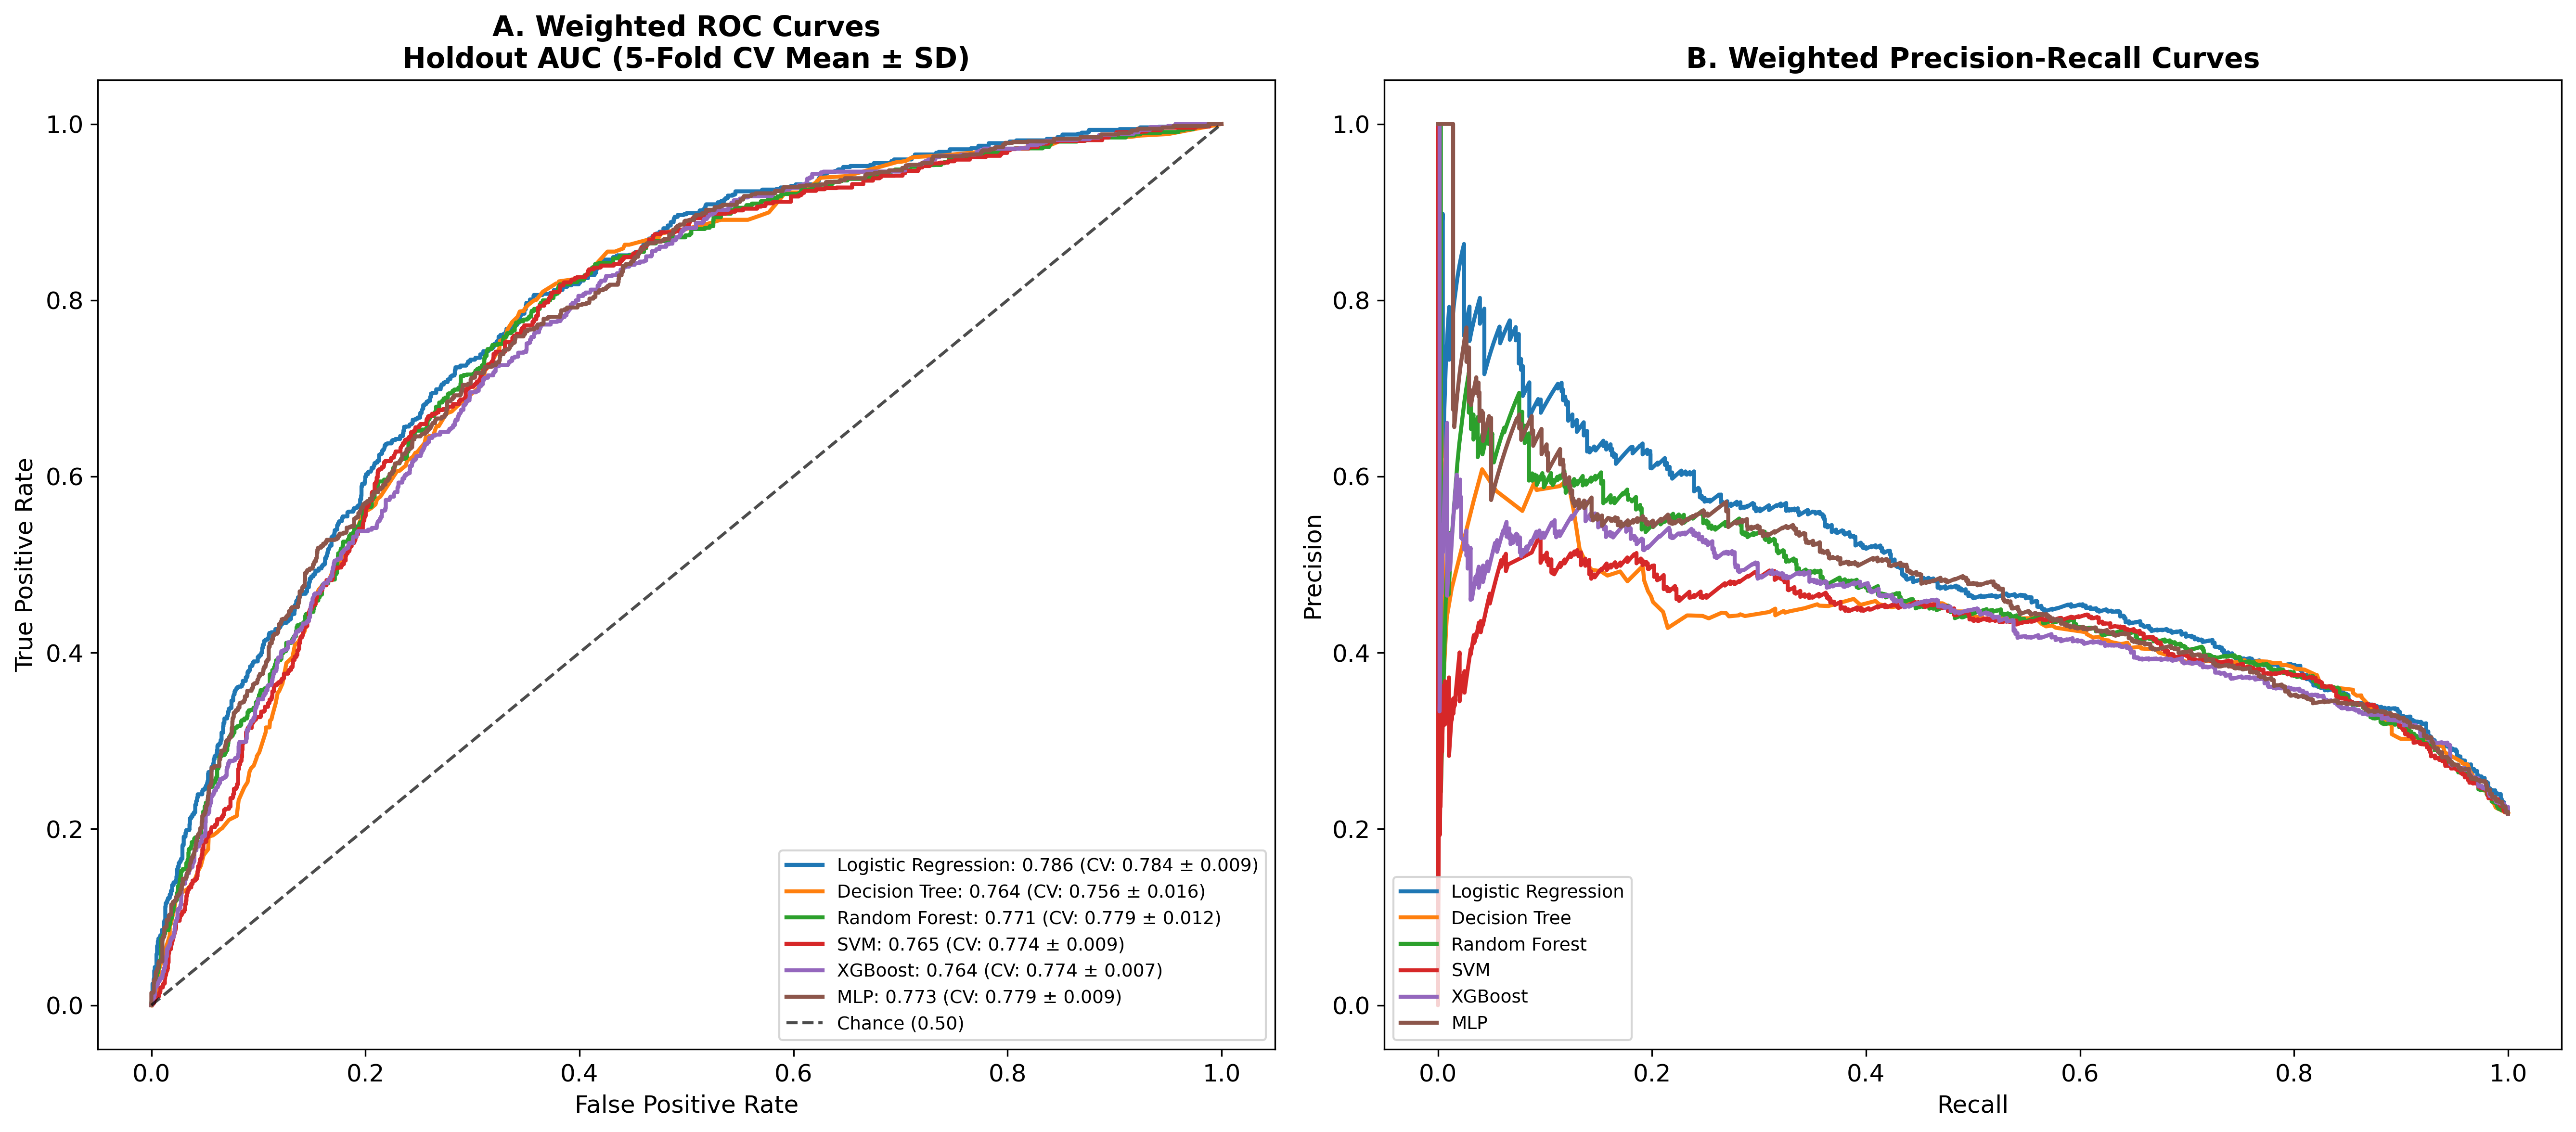

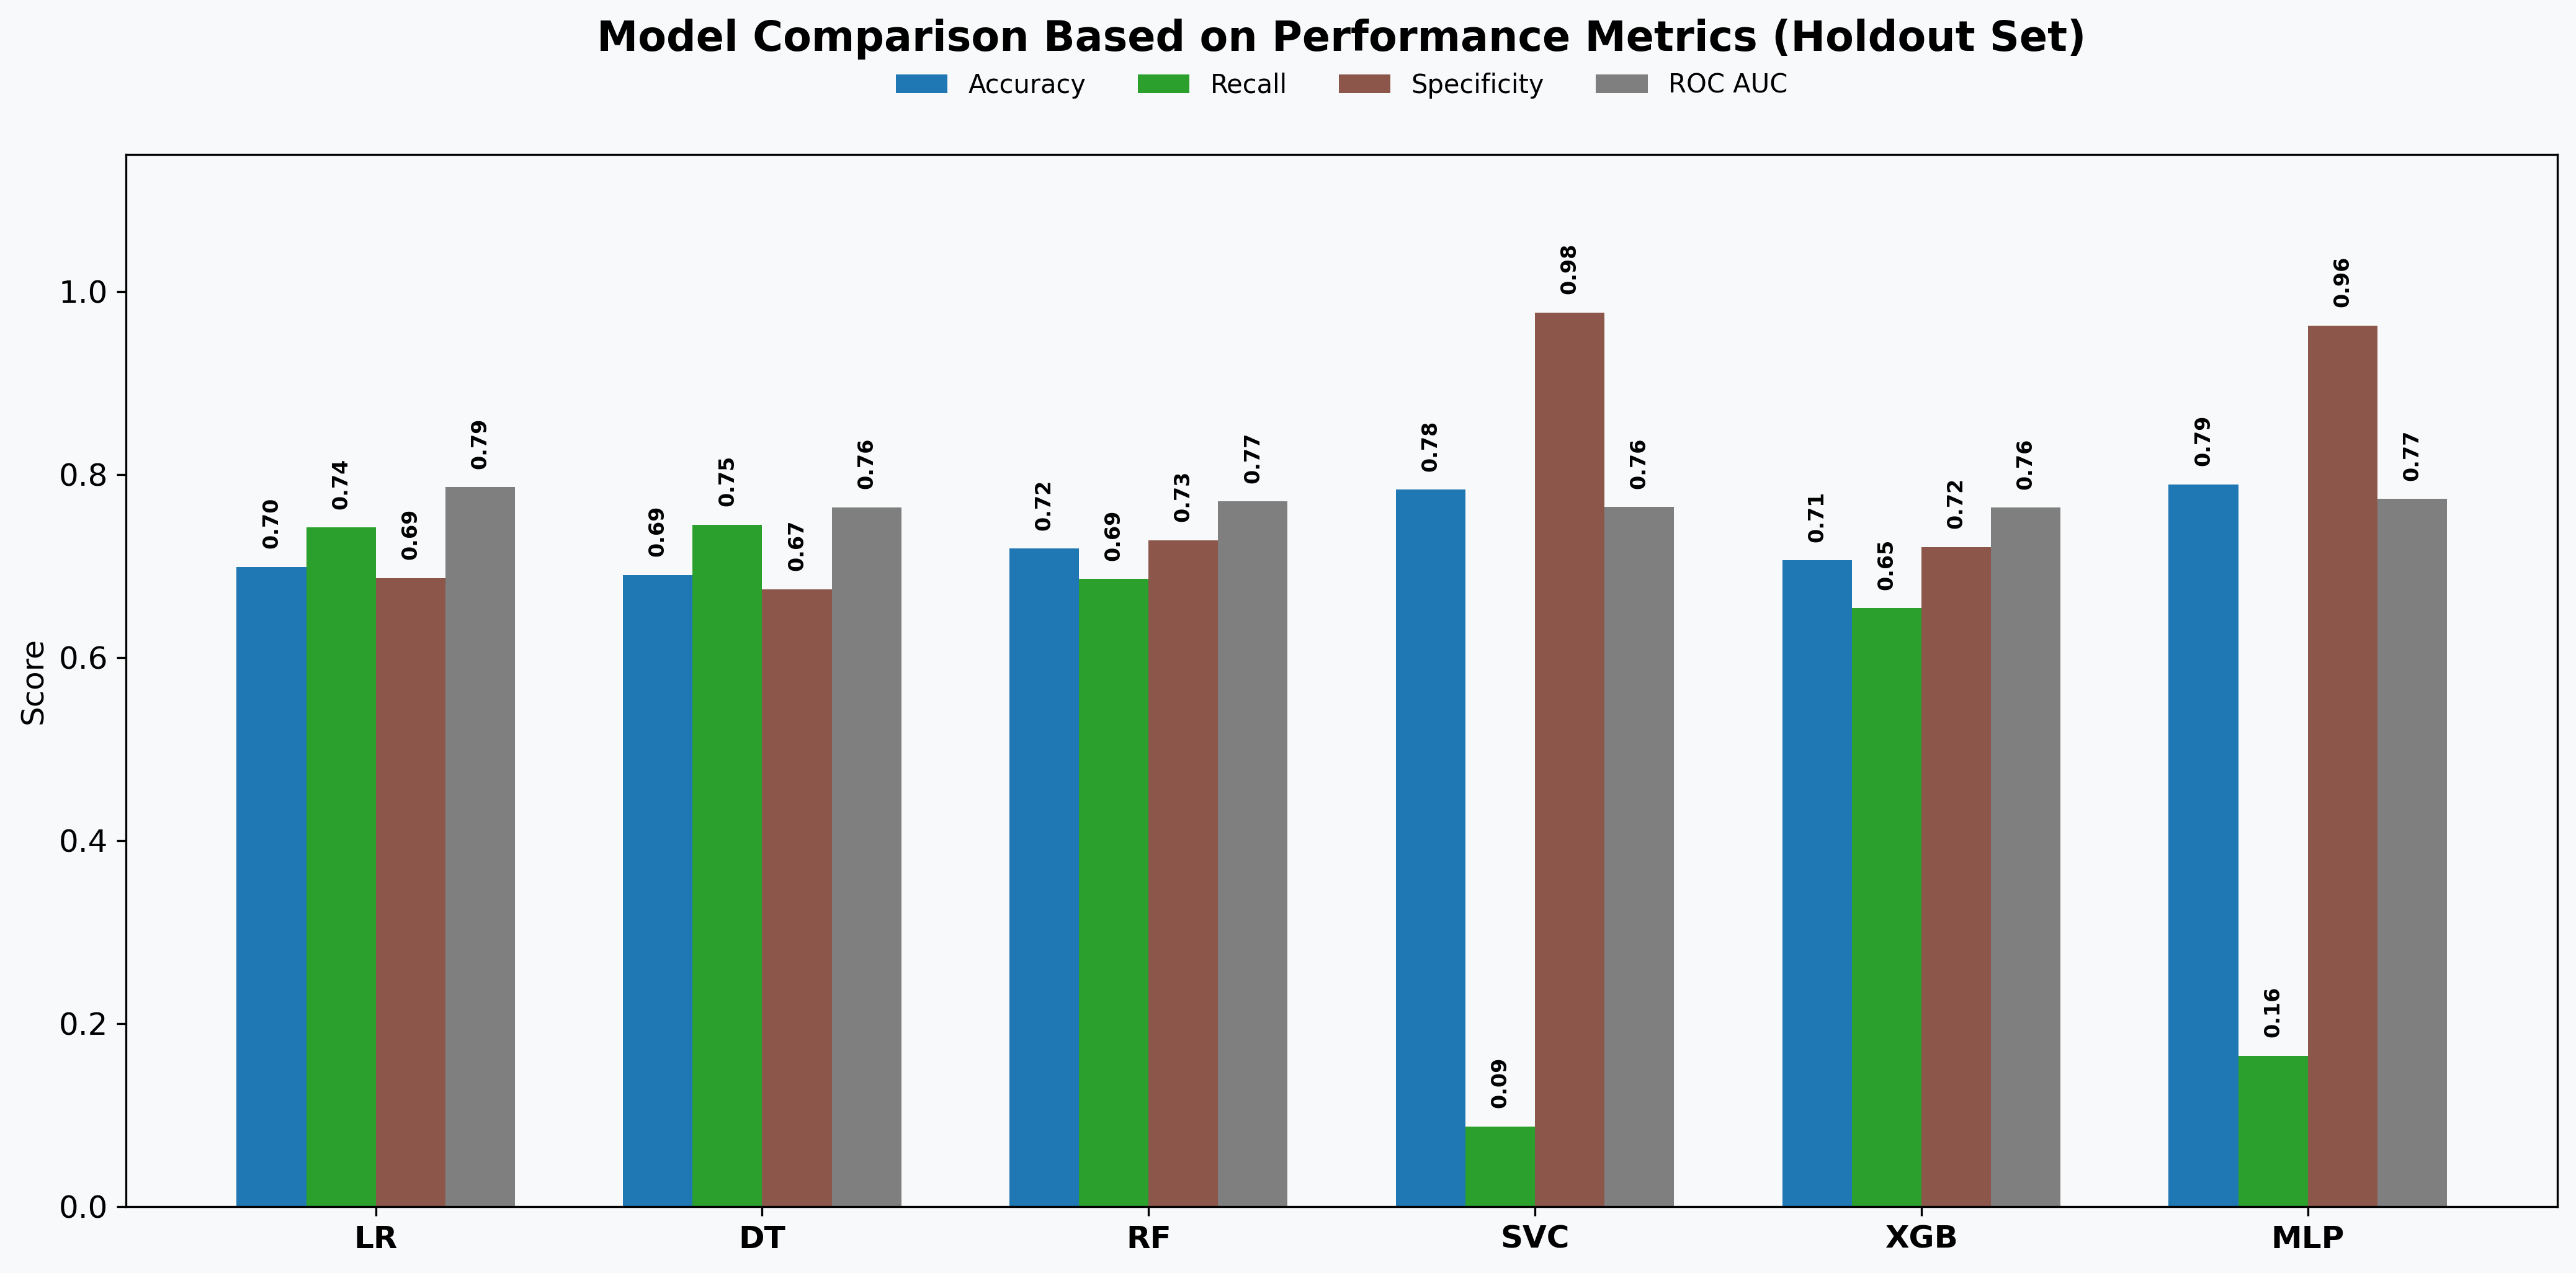

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    brier_score_loss,
    average_precision_score,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ==============================================================
# PUBLICATION-QUALITY SETTINGS
# ==============================================================
plt.style.use("default")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 300
})

# ==============================================================
# 1. LOAD & PREPROCESS DATA
# ==============================================================
df = pd.read_csv("/content/BDHS_2022_HYPERTENSION_SELECTED_VARIABLES.csv")

target = "hypertension"
design_cols = ["cluster_id", "strata_id", "sample_weight"]
df[target] = df[target].astype(int)

categorical_vars = [
    'age_group', 'sex', 'education_level', 'marital_status',
    'residence_type', 'division', 'wealth_index', 'BMI_category',
    'diabetes', 'household_size_cat', 'crowding_category',
    'electricity', 'improved_water', 'improved_toilet', 'mobile_phone'
]

for col in categorical_vars:
    df[col] = df[col].astype(str)

X = pd.get_dummies(df.drop(columns=[target] + design_cols), drop_first=True)
y = df[target]
w = df["sample_weight"]
clusters = df["cluster_id"]

# ==============================================================
# 2. CLUSTER-AWARE SPLIT (TRAIN/VAL/TEST)
# ==============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups=clusters))

X_train_val, X_test = X.iloc[train_val_idx], X.iloc[test_idx]
y_train_val, y_test = y.iloc[train_val_idx], y.iloc[test_idx]
w_train_val, w_test = w.iloc[train_val_idx], w.iloc[test_idx]
c_train_val = clusters.iloc[train_val_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups=c_train_val))

X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
w_train, w_val = w_train_val.iloc[train_idx], w_train_val.iloc[val_idx]

# ==============================================================
# 3. EVALUATION FUNCTIONS
# ==============================================================
def evaluate_metrics(y_true, p, w, threshold=0.5):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, sample_weight=w).ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "Accuracy": accuracy_score(y_true, pred, sample_weight=w),
        "AUC": roc_auc_score(y_true, p, sample_weight=w),
        "PR_AUC": average_precision_score(y_true, p, sample_weight=w),
        "Kappa": cohen_kappa_score(y_true, pred, sample_weight=w),
        "Precision": precision_score(y_true, pred, sample_weight=w),
        "Recall": recall_score(y_true, pred, sample_weight=w),
        "F1": f1_score(y_true, pred, sample_weight=w),
        "Brier": brier_score_loss(y_true, p, sample_weight=w),
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }

# ==============================================================
# 4. MODELS DEFINITION
# ==============================================================
ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
     "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "SVM": SVC(
        C=1, kernel="rbf",gamma="scale", probability=True, class_weight="balanced", random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=1000, max_depth=4, learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5, gamma=0.2, reg_alpha=0.1,
        reg_lambda=1, scale_pos_weight=ratio,
        eval_metric="auc", tree_method="hist", random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
        alpha=0.001, early_stopping=True, max_iter=500, random_state=42
    )
}

# ==============================================================
# 5. CROSS-VALIDATION & HOLDOUT TRAINING
# ==============================================================
master_results = []
roc_plot_data = {}

# Part A: 5-Fold Group CV
gkf = GroupKFold(n_splits=5)
cv_results = []

for name, model in models.items():
    print(f"Running CV: {name}")
    for tr, te in gkf.split(X, y, groups=clusters):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr, w_te = w.iloc[tr], w.iloc[te]

        if name == "MLP": model.fit(X_tr, y_tr)
        else: model.fit(X_tr, y_tr, sample_weight=w_tr)

        p = model.predict_proba(X_te)[:, 1]
        metrics = evaluate_metrics(y_te, p, w_te)
        metrics["Model"] = name
        cv_results.append(metrics)

cv_df = pd.DataFrame(cv_results)
cv_summary = cv_df.groupby("Model")["AUC"].agg(["mean", "std"]).to_dict('index')

# Part B: Holdout Training
for name, model in models.items():
    print(f"Training Final: {name}")
    if name == "MLP": model.fit(X_train, y_train)
    else: model.fit(X_train, y_train, sample_weight=w_train)

    p_test = model.predict_proba(X_test)[:, 1]
    test_metrics = evaluate_metrics(y_test, p_test, w_test)

    res = {"Model": f"{name} (Test)"}
    res.update(test_metrics)
    master_results.append(res)
    roc_plot_data[name] = p_test

results_df = pd.DataFrame(master_results)

# ==============================================================
# 6. VISUALIZATION 1: ROC & PR CURVES
# ==============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for name, probs in roc_plot_data.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs, sample_weight=w_test)
    holdout_auc = roc_auc_score(y_test, probs, sample_weight=w_test)
    cv_mean = cv_summary[name]['mean']
    cv_std = cv_summary[name]['std']

    label_str = f"{name}: {holdout_auc:.3f} (CV: {cv_mean:.3f} ± {cv_std:.3f})"
    ax1.plot(fpr, tpr, linewidth=2, label=label_str)

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, probs, sample_weight=w_test)
    ax2.plot(recall, precision, linewidth=2, label=name)

# Styling
ax1.plot([0, 1], [0, 1], '--k', alpha=0.7, label="Chance (0.50)")
ax1.set_title("A. Weighted ROC Curves\nHoldout AUC (5-Fold CV Mean ± SD)", fontweight='bold')
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlabel("False Positive Rate"), ax1.set_ylabel("True Positive Rate")

ax2.set_title("B. Weighted Precision-Recall Curves", fontweight='bold')
ax2.legend(loc="lower left", fontsize=9)
ax2.set_xlabel("Recall"), ax2.set_ylabel("Precision")

plt.tight_layout()
plt.savefig("ROC_PR_Comparison.png", dpi=300)
plt.show()

# ==============================================================
# 7. VISUALIZATION 2: PERFORMANCE BAR CHART
# ==============================================================
name_mapping = {
    "Logistic Regression (Test)": "LR", "Decision Tree (Test)": "DT",
    "Random Forest (Test)": "RF", "SVM (Test)": "SVC",
    "XGBoost (Test)": "XGB", "MLP (Test)": "MLP"
}

plot_df = results_df.copy()
plot_df['Model_Short'] = plot_df['Model'].map(name_mapping)

metrics_to_plot = ["Accuracy", "Recall", "Specificity", "AUC"]
display_labels = ['Accuracy', 'Recall', 'Specificity', 'ROC AUC']
colors = ['#1f77b4', '#2ca02c', '#8c564b', '#7f7f7f']

x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

for i, col in enumerate(metrics_to_plot):
    bars = ax.bar(x + i*width, plot_df[col], width, label=display_labels[i], color=colors[i])

    # Annotate values on top of bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', rotation=90, fontsize=8, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_df['Model_Short'], fontweight='bold')
ax.set_title("Model Comparison Based on Performance Metrics (Holdout Set)",
             fontweight='bold', fontsize=16, pad=40)
ax.set_ylabel("Score"), ax.set_ylim(0, 1.15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=4, frameon=False)

plt.tight_layout()
plt.savefig("Model_Metrics_Comparison.png", dpi=300)
plt.show()

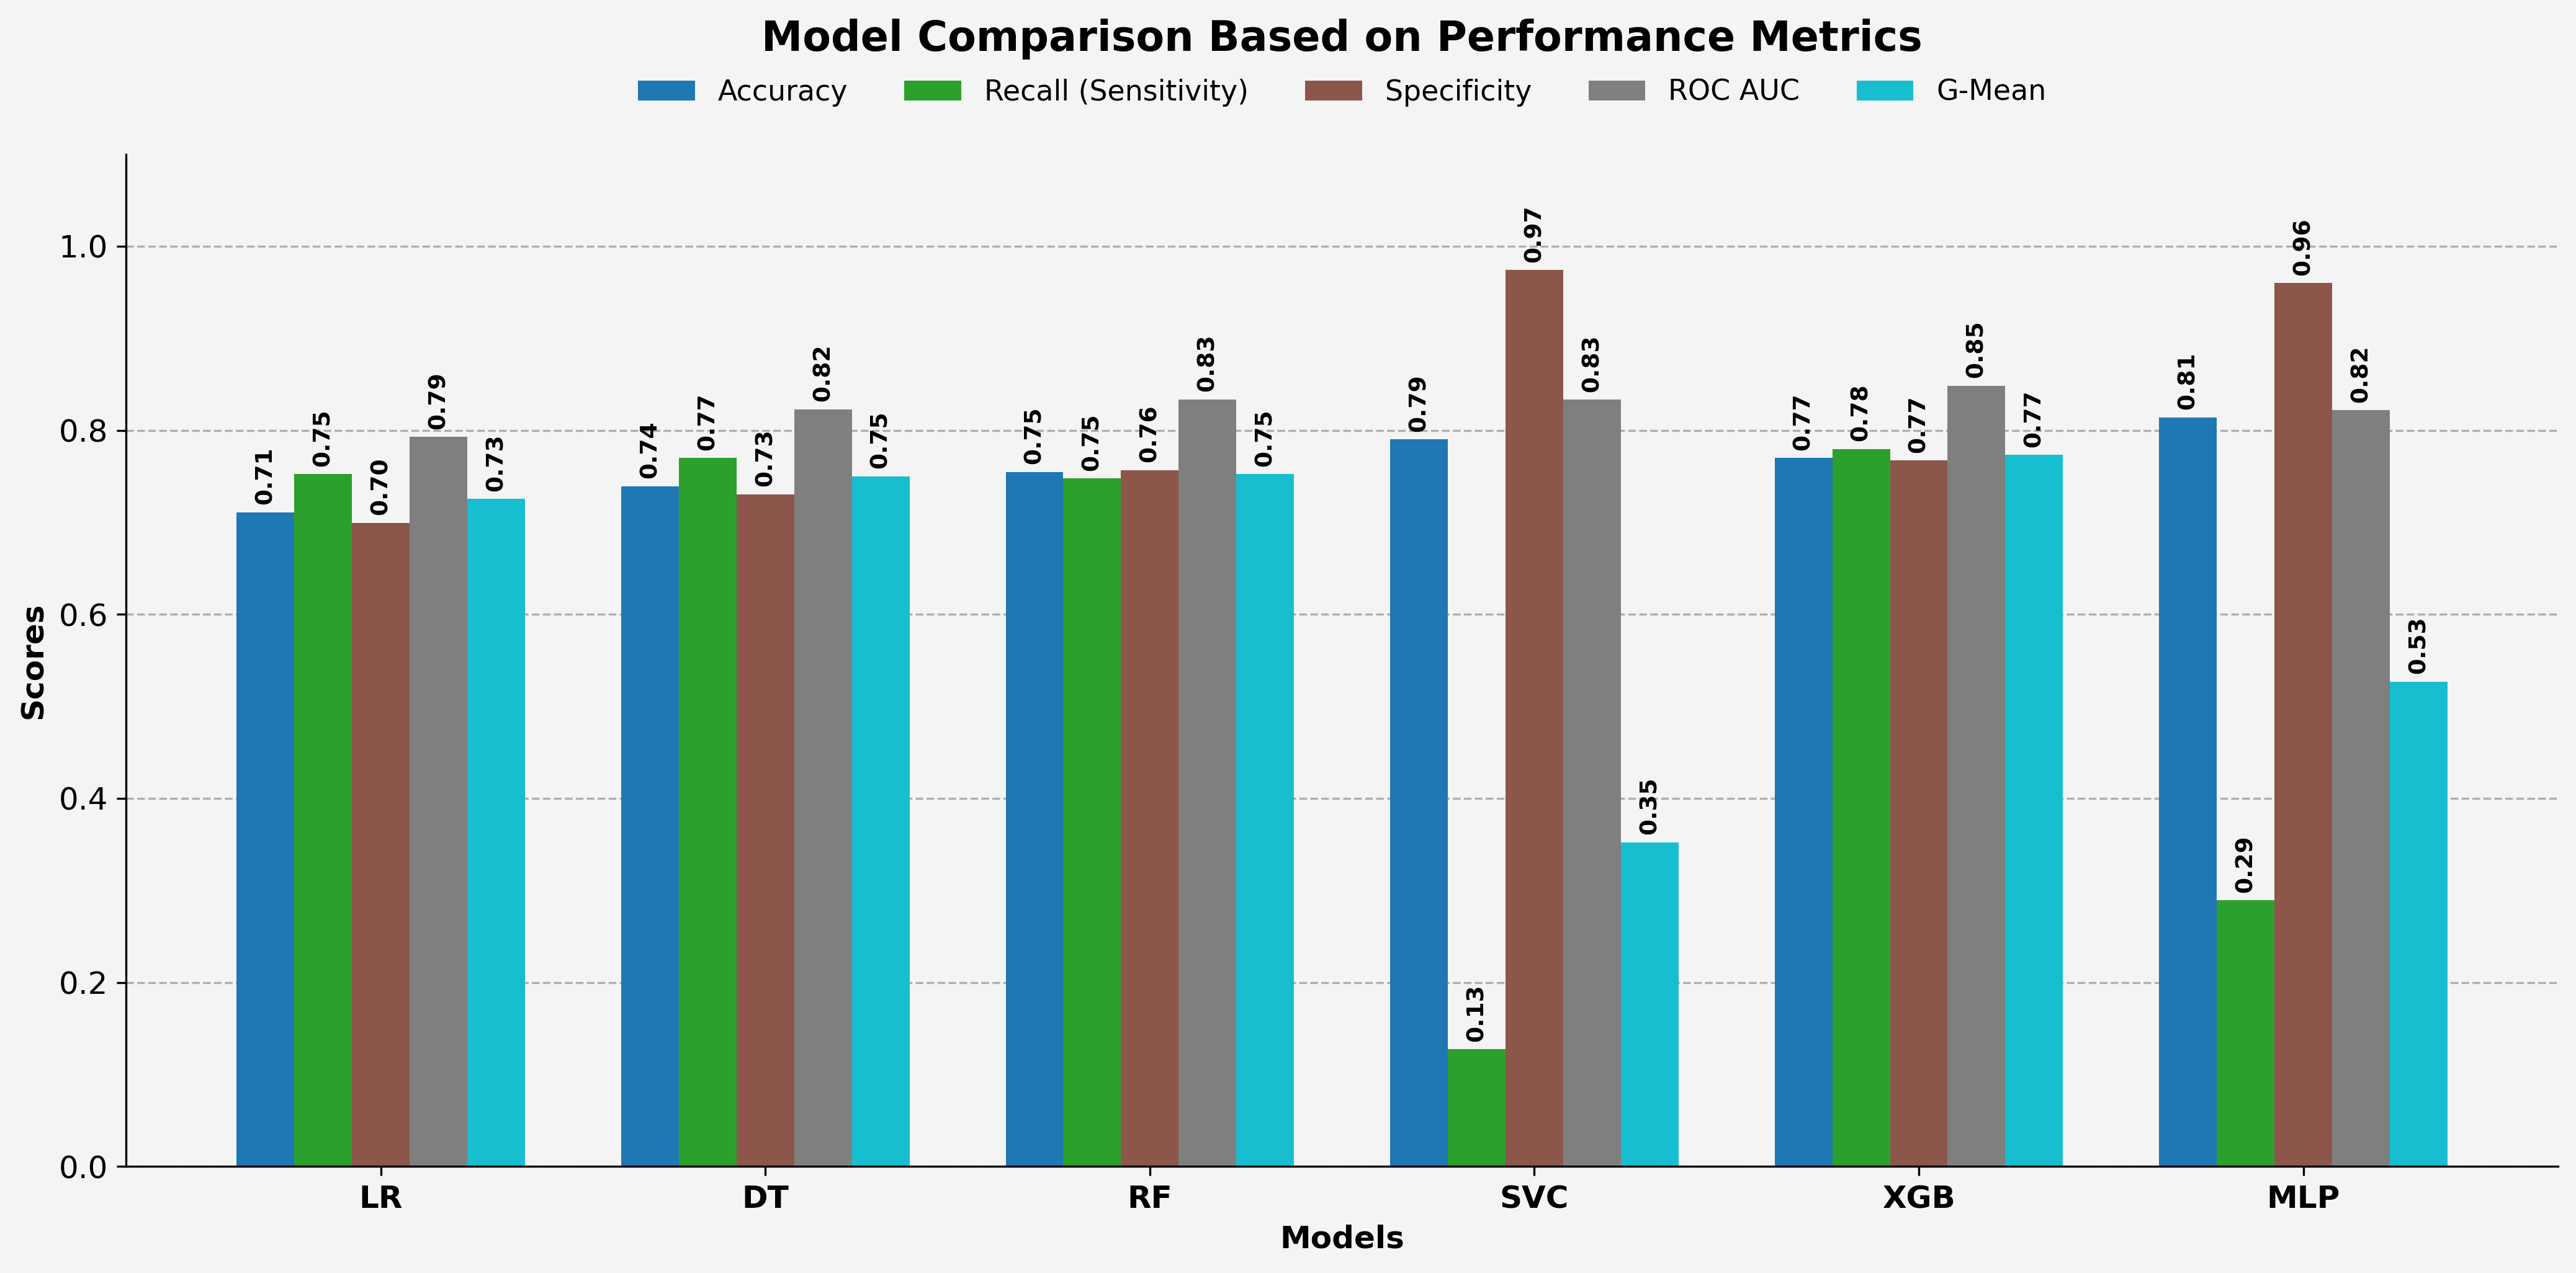

In [ ]:
# ==============================================================
# 11. MODEL COMPARISON BAR PLOT (STYLED LIKE image_ae5a66.png)
# ==============================================================

# 1. Filter results to show only Holdout 'Test' metrics
plot_df = results_df[results_df['Model'].str.contains("(Test)")].copy()

# 2. Clean model names for x-axis abbreviations
name_mapping = {
    "Logistic Regression (Test)": "LR",
    "Decision Tree (Test)": "DT",
    "Random Forest (Test)": "RF",
    "SVM (Test)": "SVC",
    "XGBoost (Test)": "XGB",
    "MLP (Test)": "MLP"
}
plot_df['Model_Short'] = plot_df['Model'].map(name_mapping)

# 3. Calculate G-Mean: sqrt(Sensitivity * Specificity)
plot_df['G-Mean'] = np.sqrt(plot_df['Sensitivity'] * plot_df['Specificity'])

# 4. Select and reorder columns to match the reference image
metrics_to_plot = ["Accuracy", "Recall", "Specificity", "AUC", ]
plot_data = plot_df.set_index('Model_Short')[metrics_to_plot]

# 5. Plotting
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f4f4f4')
ax.set_facecolor('#f4f4f4')

# Colors matching image_ae5a66.png
colors = ['#1f77b4', '#2ca02c', '#8c564b', '#7f7f7f', '#17becf']
labels = ['Accuracy', 'Recall (Sensitivity)', 'Specificity', 'ROC AUC']

# Create grouped bars
x = np.arange(len(plot_data))
width = 0.15

for i, col in enumerate(metrics_to_plot):
    bars = ax.bar(x + i*width, plot_data[col], width, label=labels[i], color=colors[i])

    # Add data labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=90, fontsize=9, fontweight='bold')

# Formatting to match image_ae5a66.png
ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_data.index, fontweight='bold')
ax.set_ylabel('Scores', fontweight='bold', fontsize=12)
ax.set_xlabel('Models', fontweight='bold', fontsize=12)
ax.set_title('Model Comparison Based on Performance Metrics',
             fontweight='bold', fontsize=16, pad=40)

# Legend at the top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=5, frameon=False, fontsize=11)

# Grid and Spines
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("Model_Comparison_Metrics.png", dpi=300)
plt.show()

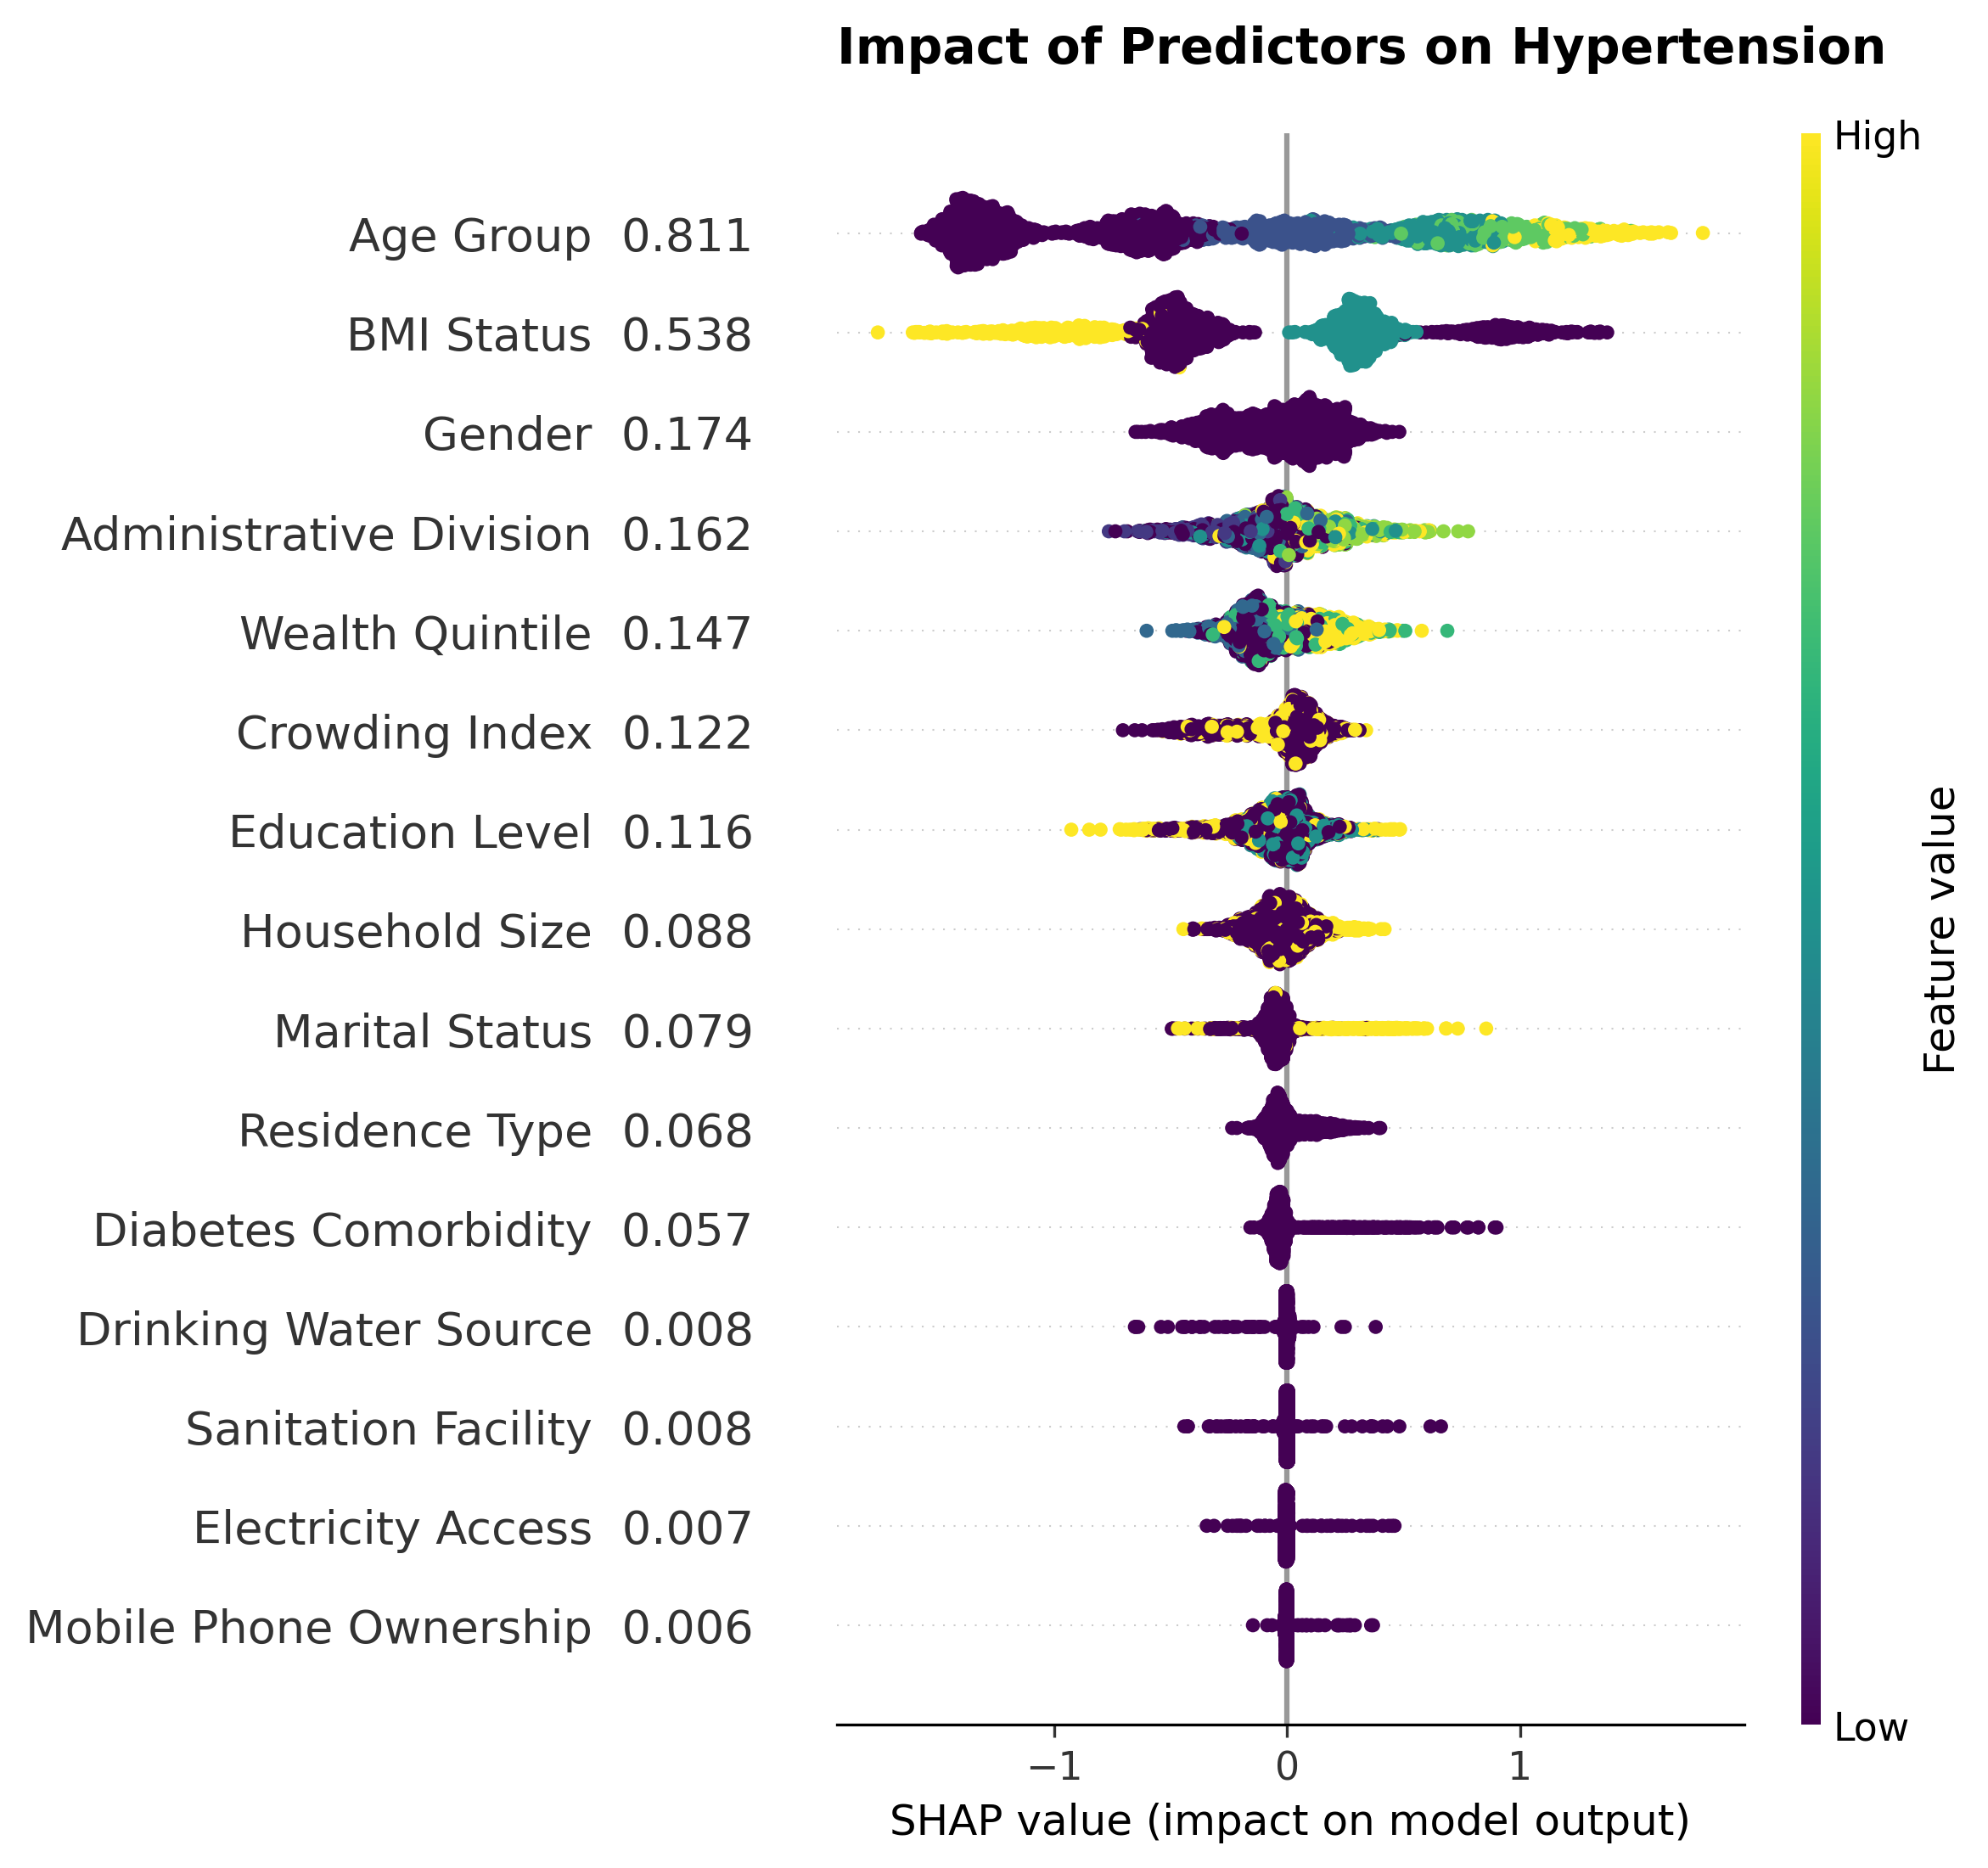

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
# 1. PROFESSIONAL FEATURE NAME MAPPING
# ==============================================================
# Maps technical column names to professional publication-ready names
name_map = {
    'age_group': 'Age Group',
    'BMI_category': 'BMI Status',
    'wealth_index': 'Wealth Quintile',
    'division': 'Administrative Division',
    'sex': 'Gender',
    'education_level': 'Education Level',
    'marital_status': 'Marital Status',
    'residence_type': 'Residence Type',
    'diabetes': 'Diabetes Comorbidity',
    'household_size_cat': 'Household Size',
    'crowding_category': 'Crowding Index',
    'electricity': 'Electricity Access',
    'improved_water': 'Drinking Water Source',
    'improved_toilet': 'Sanitation Facility',
    'mobile_phone': 'Mobile Phone Ownership'
}

# --- Aggregation and Setup ---
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values_raw = explainer.shap_values(X_test)

X_test_parent = pd.DataFrame(index=X_test.index)
shap_list = []
feature_names_clean = []

for tech, prof in name_map.items():
    relevant = [c for c in X_test.columns if c.startswith(tech)]
    if relevant:
        # Sum SHAP values across categories
        agg_shap = np.sum(shap_values_raw[:, [X_test.columns.get_loc(c) for c in relevant]], axis=1)
        shap_list.append(agg_shap)
        # Numerical proxy for coloring
        X_test_parent[prof] = X_test[relevant].idxmax(axis=1).astype('category').cat.codes
        feature_names_clean.append(prof)

shap_parent_arr = np.array(shap_list).T
mean_abs = np.abs(shap_parent_arr).mean(axis=0)
sorted_idx = np.argsort(mean_abs)

# Sorting data for the plot
shap_sorted = shap_parent_arr[:, sorted_idx]
X_sorted = X_test_parent.iloc[:, sorted_idx]
labels_with_vals = [f"{feature_names_clean[i]}  {mean_abs[i]:.3f}" for i in sorted_idx]

# --- Figure 1: Summary Dot Plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_sorted,
    X_sorted,
    feature_names=labels_with_vals,
    plot_type="dot",
    cmap=plt.get_cmap("viridis"),
    show=False
)
plt.title("Impact of Predictors on Hypertension", loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.tight_layout()
plt.savefig("Hypertension_Summary_Plot.png", dpi=300)
plt.show()

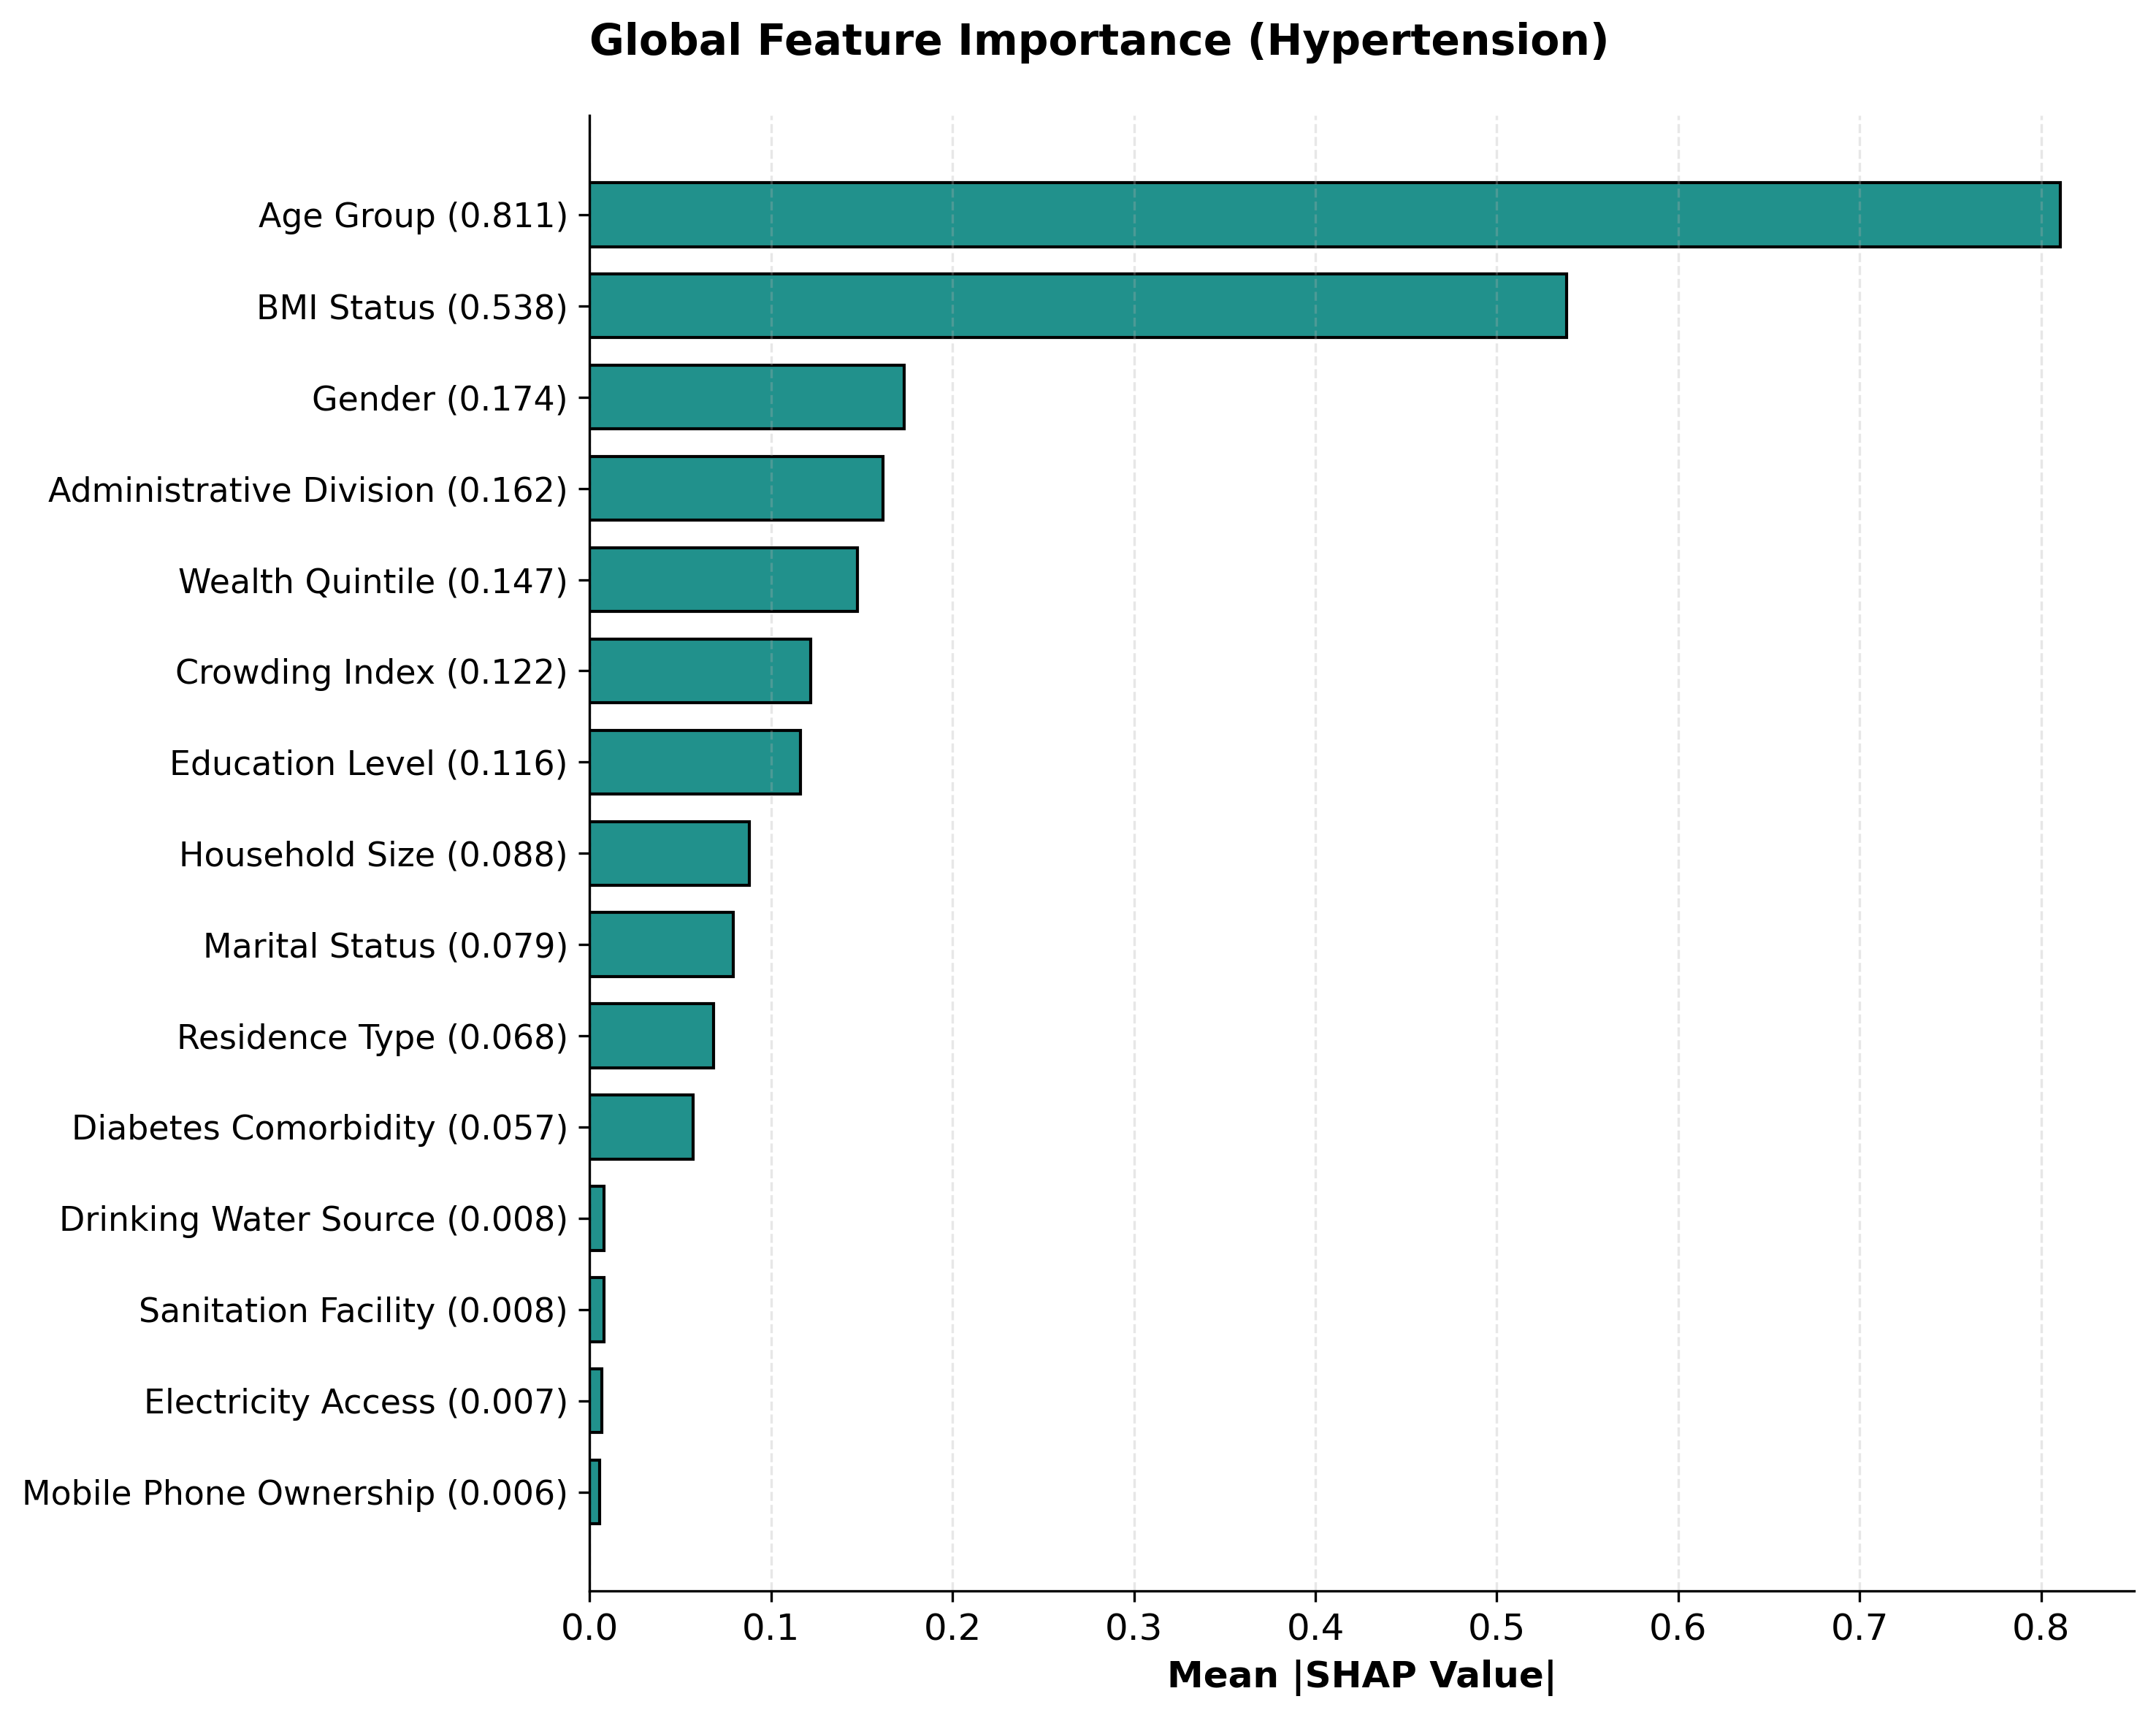

In [ ]:
# --- Figure 2: Global Importance Bar Plot ---
plt.figure(figsize=(10, 8))

# Use the same sorted indices and mean values
sorted_means = mean_abs[sorted_idx]
sorted_labels = [feature_names_clean[i] for i in sorted_idx]
# Append values to labels for professional look
final_labels = [f"{n} ({v:.3f})" for n, v in zip(sorted_labels, sorted_means)]

plt.barh(range(len(final_labels)), sorted_means, color="#21918c", edgecolor="black", height=0.7)

# Styling
plt.yticks(range(len(final_labels)), final_labels, fontsize=11)
plt.xlabel("Mean |SHAP Value|", fontsize=12, fontweight='bold')
plt.title("Global Feature Importance (Hypertension)", loc='left', fontsize=14, fontweight='bold', pad=20)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("Hypertension_Global_Importance.png", dpi=300)
plt.show()